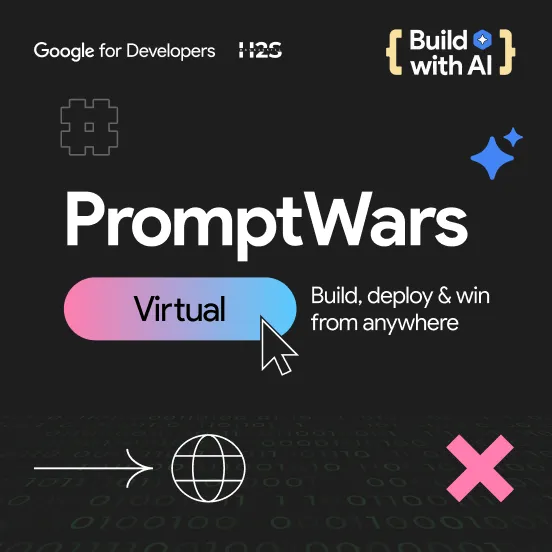

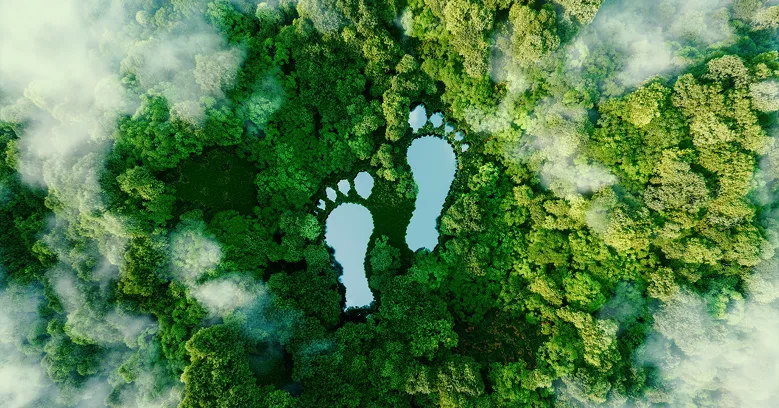

### **Challenge 3 : Carbon Footprint Awareness Platform**

*Design a solution that helps individuals understand, track, and reduce their carbon footprint through simple actions and personalized insights.*

***Prototype bulit-up by Deepak Kaura (AI Devilops)***

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# -----------------------------
# Load and prepare your data
# -----------------------------
df = pd.read_csv('/content/personal_carbon_footprint_behavior.csv')

df.head()

,user_id,day_type,transport_mode,distance_km,electricity_kwh,renewable_usage_pct,food_type,screen_time_hours,waste_generated_kg,eco_actions,carbon_footprint_kg,carbon_impact_level
0,1,Weekend,EV,1.55,6.12,0,Non-Veg,2.4,0.70,1,11.03,High
1,1,Weekend,Walk,10.04,4.50,0,Mixed,4.1,0.54,1,7.44,Medium
2,1,Weekday,Walk,15.27,2.81,0,Mixed,4.0,0.51,1,6.01,Medium
3,1,Weekend,Walk,0.50,10.16,0,Mixed,6.3,0.73,0,12.70,High
4,1,Weekend,Walk,3.60,5.02,50,Mixed,5.1,0.64,0,6.33,Medium


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1400 entries, 0 to 1399
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              1400 non-null   int64  
 1   day_type             1400 non-null   object 
 2   transport_mode       1400 non-null   object 
 3   distance_km          1400 non-null   float64
 4   electricity_kwh      1400 non-null   float64
 5   renewable_usage_pct  1400 non-null   int64  
 6   food_type            1400 non-null   object 
 7   screen_time_hours    1400 non-null   float64
 8   waste_generated_kg   1400 non-null   float64
 9   eco_actions          1400 non-null   int64  
 10  carbon_footprint_kg  1400 non-null   float64
 11  carbon_impact_level  1400 non-null   object 
dtypes: float64(5), int64(3), object(4)
memory usage: 131.4+ KB


In [ ]:
df.day_type.value_counts()

,count
day_type,
Weekday,721
Weekend,679


In [ ]:
df.food_type.value_counts()

,count
food_type,
Non-Veg,474
Mixed,472
Veg,454


In [ ]:
df.transport_mode.value_counts()

,count
transport_mode,
Bike,291
Walk,290
Bus,276
EV,272
Car,271


In [ ]:
df.carbon_impact_level.value_counts()

,count
carbon_impact_level,
Medium,869
Low,337
High,194


In [ ]:
df['carbon_impact_level'] = df['carbon_impact_level'].map({
    "Low": 2,
    "Medium": 1,
    "High": 3
})

In [ ]:
df['transport_mode'] = df['transport_mode'].map({
    "Car": 4,
    "Bike": 0,
    "Walk": 1,
    "Bus" : 2,
    "EV" : 3
})

In [ ]:
df['food_type'] = df['food_type'].map({
    "Veg": 2,
    "Non-Veg": 0,
    "Mixed" : 1
})

In [ ]:
df['day_type'] = df['day_type'].map({
    "Weekday": 0,
    "Weekend": 1

})

In [ ]:
# Select features for clustering
features = df[["day_type",
"transport_mode",
"distance_km",
"electricity_kwh",
"renewable_usage_pct",
"food_type",
"screen_time_hours",
"waste_generated_kg",
"eco_actions"]]

# -----------------------------
# Scale features — very important for K-Means
# -----------------------------
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

In [ ]:
# -----------------------------
# Find optimal k with Elbow Method
# -----------------------------
inertia = []
k_range = range(2, 10)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(features_scaled)
    inertia.append(kmeans.inertia_)  # Distortion / SSE

import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=list(k_range),
        y=inertia,
        mode='lines+markers',
        marker=dict(color='royalblue', size=8),
        line=dict(width=2),
        name='Inertia'
    )
)

fig.update_layout(
    title='Elbow Method For Optimal k',
    xaxis_title='Number of clusters (k)',
    yaxis_title='Inertia (SSE)',
    xaxis=dict(tickmode='linear'),
    template='plotly_white',
    width=800,
    height=500
)

fig.show()


In [ ]:
# Suppose you choose k= from the elbow
optimal_k = 4

kmeans_final = KMeans(n_clusters=optimal_k, random_state=42)
df['Carbon_Impact_Type'] = kmeans_final.fit_predict(features_scaled)

# Select columns by passing a list of column names
print(df.groupby('Carbon_Impact_Type')[features.columns].mean())

                    day_type  transport_mode  distance_km  electricity_kwh  \
Carbon_Impact_Type                                                           
0                   0.010929        1.898907    11.690820         5.370546   
1                   0.991643        2.259053     6.152786         4.850390   
2                   0.025568        1.812500    12.359347         6.500256   
3                   0.959752        1.851393     5.914303         7.235356   

                    renewable_usage_pct  food_type  screen_time_hours  \
Carbon_Impact_Type                                                      
0                             31.762295   1.579235           5.856284   
1                             30.919220   1.167131           5.642061   
2                             31.036932   0.323864           5.139205   
3                             32.739938   0.832817           5.426006   

                    waste_generated_kg  eco_actions  
Carbon_Impact_Type                    

In [ ]:
cluster_avg = (
    df.groupby("Carbon_Impact_Type")[features.columns]
      .mean()
      .sort_values(by=['distance_km','electricity_kwh'])
)
ordered_clusters = cluster_avg.index.tolist()

In [ ]:
ordered_clusters

[3, 1, 0, 2]

In [ ]:
# Make a mapping
segment_names = ["Home-Centric Consumers", "Passive Consumers", "Frequent Commuters", "Carbon Intensive Users"]
cluster_to_label = {cluster: segment_names[i] for i, cluster in enumerate(ordered_clusters)}

# Apply mapping
df["Carbon_Impact_Label"] = df["Carbon_Impact_Type"].map(cluster_to_label)

print(df[["user_id","Carbon_Impact_Type", "Carbon_Impact_Label"]].head())
print('--' * 22)
print(df[["Carbon_Impact_Type", "Carbon_Impact_Label"]].value_counts())

   user_id  Carbon_Impact_Type     Carbon_Impact_Label
0        1                   3  Home-Centric Consumers
1        1                   1       Passive Consumers
2        1                   0      Frequent Commuters
3        1                   3  Home-Centric Consumers
4        1                   1       Passive Consumers
--------------------------------------------
Carbon_Impact_Type  Carbon_Impact_Label   
0                   Frequent Commuters        366
1                   Passive Consumers         359
2                   Carbon Intensive Users    352
3                   Home-Centric Consumers    323
Name: count, dtype: int64


In [ ]:
df_numeric = df.select_dtypes(include=['number'])
corr = df_numeric.corr()

import plotly.express as px

fig = px.imshow(
    corr,
    text_auto=".2f",
    color_continuous_scale='RdBu_r',
    title="Correlation Heatmap (Numeric Columns Only)"
)

fig.update_layout(
    width=1000,
    height=800
)

fig.show()


In [ ]:
df.columns

Index(['user_id', 'day_type', 'transport_mode', 'distance_km',
       'electricity_kwh', 'renewable_usage_pct', 'food_type',
       'screen_time_hours', 'waste_generated_kg', 'eco_actions',
       'carbon_footprint_kg', 'carbon_impact_level', 'Carbon_Impact_Type',
       'Carbon_Impact_Label'],
      dtype='object')

In [ ]:
corr_features = [
    'user_id', 'day_type', 'transport_mode', 'distance_km',
       'electricity_kwh', 'renewable_usage_pct', 'food_type',
       'screen_time_hours', 'waste_generated_kg', 'eco_actions',
       'carbon_footprint_kg', 'Carbon_Impact_Type', 'carbon_impact_level',


]

import plotly.express as px
import plotly.graph_objects as go

# Calculate correlation matrix again
corr_matrix = df[corr_features].corr()

# Select only correlations with target column
target_corr = corr_matrix[['carbon_impact_level']].drop(index='carbon_impact_level').reset_index()
target_corr.columns = ['Feature', 'Correlation']
target_corr['AbsCorrelation'] = target_corr['Correlation'].abs()

# Sort by absolute correlation
target_corr = target_corr.sort_values(by='AbsCorrelation', ascending=False)

fig = px.bar(
    target_corr,
    x='Feature',
    y='Correlation',
    color='Correlation',
    title='Feature Correlations with Carbon Impact Level',
    color_continuous_scale='earth',
    text=target_corr['Correlation'].round(3)
)

fig.update_layout(
    width=900,
    height=650,
    xaxis_title='Feature',
    yaxis_title='Correlation with Carbon Impact Level',
    bargap=0.3
)

fig.update_traces(
    textposition='outside'
)

fig.show()

In [ ]:
# ✅ Example
selected_features = ['user_id', 'day_type', 'transport_mode', 'distance_km',
       'electricity_kwh', 'renewable_usage_pct', 'food_type', 'waste_generated_kg',
       'carbon_footprint_kg', 'Carbon_Impact_Type'

]

# Create a new DataFrame for X (features)
X = df[selected_features]

# Target variable
y = df['carbon_impact_level']


In [ ]:
from sklearn.model_selection import train_test_split

# Split without SMOTE
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,

)


In [ ]:

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
import plotly.figure_factory as ff



# 2. HistGradientBoosting Classifier
hgb = HistGradientBoostingClassifier(random_state=42)
hgb.fit(X_train, y_train)
y_pred_hgb = hgb.predict(X_test)
print('----' * 18)
print(f"📊 HistGradientBoosting Accuracy: {accuracy_score(y_test, y_pred_hgb):.2f}")
print('----' * 18)


# Confusion matrix
cm = confusion_matrix(y_test, y_pred_hgb)

# Plot confusion matrix using Plotly
labels = ["High","Low","Medium"]
z_text = [[str(y) for y in x] for x in cm]

fig = ff.create_annotated_heatmap(
    z=cm,
    x=labels,
    y=labels,
    annotation_text=z_text,
    colorscale='Blues',
    showscale=True
)

fig.update_layout(
    title_text='Confusion Matrix - HistGradientBoosting Classifier',
    width=550,
    height=500
)

fig['data'][0]['showscale'] = True
fig.show()


------------------------------------------------------------------------
📊 HistGradientBoosting Accuracy: 0.99
------------------------------------------------------------------------


In [ ]:
X_test['Predicted_Carbon_Impact_Level'] = y_pred_hgb

In [ ]:
Predicted_Carbon_Impact_Level_map = {
    3: 'High',
    1: 'Medium',
    2: 'Low'
}



Transport_Mode_map = {
    4: 'Car',
    0: 'Bike',
    1: 'Walk',
    2: 'Bus',
    3: 'EV'
}

Food_Type_map = {
    2: 'Veg',
    0: 'Non-Veg',
    1: 'Mixed'
}

Day_Type_map = {
    0: 'Weekday',
    1: 'Weekend'
}

X_test['transport_mode'] = X_test['transport_mode'].map(Transport_Mode_map)
X_test['food_type'] = X_test['food_type'].map(Food_Type_map)
X_test['day_type'] = X_test['day_type'].map(Day_Type_map)
X_test['Predicted_Carbon_Impact_Level'] = X_test['Predicted_Carbon_Impact_Level'].map(Predicted_Carbon_Impact_Level_map)

In [ ]:
X_test

,user_id,day_type,transport_mode,distance_km,electricity_kwh,renewable_usage_pct,food_type,waste_generated_kg,carbon_footprint_kg,Carbon_Impact_Type,Predicted_Carbon_Impact_Level
665,96,Weekday,Bike,9.61,4.02,0,Veg,0.56,5.56,0,Low
624,90,Weekday,Walk,8.06,7.57,0,Mixed,0.83,10.30,2,Medium
115,17,Weekend,Car,5.88,5.06,50,Non-Veg,0.18,9.03,1,Medium
478,69,Weekday,Bike,11.26,7.95,75,Veg,0.47,3.80,0,Low
233,34,Weekday,Bus,10.25,8.59,75,Veg,0.56,4.85,0,Low
...,...,...,...,...,...,...,...,...,...,...,...
188,27,Weekday,Bike,13.89,5.68,50,Veg,0.58,5.02,0,Low
1091,156,Weekday,Walk,11.79,4.86,50,Veg,0.40,3.27,0,Low
377,54,Weekday,Bike,13.99,4.10,50,Veg,0.63,4.04,0,Low
351,51,Weekday,Walk,6.70,9.01,0,Mixed,0.78,11.82,2,High


In [ ]:
X_test.to_csv('Carbon Impact Test.csv', index=False)

In [1]:
import pandas as pd

# Load the CSV file into a DataFrame

X_test_df = pd.read_csv('Carbon Impact Test.csv')

In [2]:
!pip install -U langchain langchain-core langchain-community


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.0/133.0 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 557.4/557.4 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 36.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 48.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 246.1/246.1 kB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 7.9 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
  Attempting uninstall: langchain-protocol
    Found existing installation: langchain-protocol 0.0.16
    Uninstalling langchain-protocol-0.0.16:
      Successfully uninstalled langchain-protocol-0.0.16
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 1.4.3
    Uninstalling langchain-core-1.4.3:
      Successfully uninstalle

In [3]:
!pip install txtai[pipeline]

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.1/70.1 MB 13.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 17.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.3/70.3 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 230.9/230.9 kB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 568.8/568.8 kB 46.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 72.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.8/207.8 kB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 30.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.5/15.5 MB 

In [4]:
from txtai.pipeline import LLM as TxtaiLLM


txtai_llm = TxtaiLLM("unsloth/gemma-4-E2B-it-qat-mobile-GGUF/gemma-4-E2B-it-qat-UD-Q2_K_XL.gguf")

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package cmudict to /root/nltk_data...
[nltk_data]   Unzipping corpora/cmudict.zip.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


gemma-4-E2B-it-qat-UD-Q2_K_XL.gguf:   0%|          | 0.00/2.19G [00:00<?, ?B/s]

llama_kv_cache_iswa: using full-size SWA cache (ref: https://github.com/ggml-org/llama.cpp/pull/13194#issuecomment-2868343055)
llama_kv_cache: the V embeddings have different sizes across layers and FA is not enabled - padding V cache to 512
llama_kv_cache: the V embeddings have different sizes across layers and FA is not enabled - padding V cache to 512


In [2]:
import os
import pandas as pd
import gradio as gr
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from txtai.pipeline import LLM as TxtaiLLM
from langchain_core.language_models.llms import BaseLLM as LangChainLLM
from langchain_core.outputs import Generation, LLMResult
from typing import List, Optional, Any

# ==========================================
# 📊 LOAD DATA DYNAMICALLY
# ==========================================
csv_filename = "Carbon Impact Test.csv"
if os.path.exists(csv_filename):
    csv_path = csv_filename
elif os.path.exists(os.path.join("..", csv_filename)):
    csv_path = os.path.join("..", csv_filename)
else:
    raise FileNotFoundError(f"Could not locate {csv_filename} in current or parent directory.")

X_test_df = pd.read_csv(csv_path)

# Ensure User ID columns are clean and sorted
X_test_df['user_id'] = X_test_df['user_id'].astype(int)
user_ids = sorted(X_test_df['user_id'].unique().tolist())

# ==========================================
# 🤖 LOAD LOCAL LLM & LANGCHAIN WRAPPER
# ==========================================
txtai_llm_instance = TxtaiLLM(
    "unsloth/gemma-4-E2B-it-qat-mobile-GGUF/gemma-4-E2B-it-qat-UD-Q2_K_XL.gguf"
)

class TxtaiLangChainLLM(LangChainLLM):
    def _generate(self, prompts: List[str], stop: Optional[List[str]] = None, **kwargs: Any) -> LLMResult:
        generations = []
        for prompt in prompts:
            response = txtai_llm_instance(prompt)
            generations.append([Generation(text=response)])
        return LLMResult(generations=generations)

    @property
    def _llm_type(self) -> str:
        return "txtai"

llm = TxtaiLangChainLLM()

# ==========================================
# ⚙️ ENHANCED RULE-BASED INSIGHTS ENGINE
# ==========================================
def generate_rule_based_insights(row):
    """
    Evaluates text and numerical data straight from the dataframe row.
    """
    insights = []

    # 1. Transportation Mode
    current_transport = str(row.get("transport_mode", "")).strip()
    if current_transport in ["Car", "Bike"]:
        insights.append(f"High-emission transport used ({current_transport}). Recommend exploring low-emission public transit or shared rides.")
    elif current_transport == "Bus":
        insights.append("Public transit (Bus) is active. Transitioning to walking/biking for shorter routes is recommended.")
    elif current_transport in ["Walk", "EV"]:
        insights.append(f"Eco-friendly transit choices ({current_transport}) are already in use! Keep it up.")

    # 2. Travel Distance
    try:
        distance = float(row["distance_km"])
        if distance > 10:
            insights.append(f"Long travel distance detected ({distance} km). Consolidate weekly trips or utilize electric vehicle options.")
    except (ValueError, TypeError):
        pass

    # 3. Energy parameters
    try:
        electricity = float(row["electricity_kwh"])
        if electricity > 6:
            insights.append(f"High electricity consumption ({electricity} kWh). Requires energy-efficient appliances or usage optimization.")
    except (ValueError, TypeError):
        pass

    try:
        renewable = float(row["renewable_usage_pct"])
        if renewable < 30:
            insights.append(f"Low renewable energy footprint ({renewable}%). Look into clean/solar alternatives or green energy tariffs.")
        elif renewable >= 70:
            insights.append(f"Excellent renewable energy integration ({renewable}%)!")
    except (ValueError, TypeError):
        pass

    # 4. Food type
    current_food = str(row.get("food_type", "")).strip()
    if current_food == "Non-Veg":
        insights.append("Non-Vegetarian dietary footprint detected. Incorporating plant-based meals weekly will significantly reduce emissions.")
    elif current_food == "Mixed":
        insights.append("Mixed diet detected. Shifting towards higher veggie proportions reduces emissions.")
    elif current_food == "Veg":
        insights.append("Vegetarian lifestyle choice confirmed. Highly eco-friendly!")

    # 5. Waste thresholds
    try:
        waste = float(row["waste_generated_kg"])
        if waste > 0.75:
            insights.append(f"Elevated waste output ({waste} kg). Target reductions via composting, reusing, and recycling.")
    except (ValueError, TypeError):
        pass

    if not insights:
        insights.append("Outstanding eco-friendly baseline values achieved. Maintain current lifestyle patterns!")

    return insights

# ==========================================
# 📝 ENHANCED UNIFIED PROMPT TEMPLATES
# ==========================================
SYSTEM_PROMPT = """
You are an AI Carbon Footprint Advisor and sustainability coach.
Your goal is to help users understand their carbon footprint dynamically and guide them toward net-zero living.

Tasks:
1. Explain the user's carbon impact level and assign a creative, highly descriptive 'Carbon Persona' matching their specific habits (e.g. 'Gas-Guzzling Commuter', 'Eco-Conscious Veggie', 'Coal-Powered Consumer').
2. Synthesize transport, energy, food, and waste habits to identify the primary causes of their footprint.
3. Deliver exactly 3 actionable, highly impactful, personalized recommendations based on the findings.
4. Estimate potential reduction benefits qualitatively (Low / Medium / High Impact).

Rules:
- Focus heavily on sustainability with a motivating, friendly, casual, and encouraging tone.
- Do not overwhelm the user; keep points brief (1-2 sentences each).
- You MUST strictly follow the requested markdown format. Do not add conversational intro/outro text.
"""

RECOMMENDATION_PROMPT = """
Based on the user's profile and rule-based insights, craft a personalized green strategy.

[USER PROFILE]:
- User ID: {user_id}
- Day Type: {day_type}
- Transport Mode: {transport_mode} (Distance: {distance_km} km)
- Electricity Usage: {electricity_kwh} kWh
- Renewable Energy Usage: {renewable_usage_pct}%
- Food Type: {food_type}
- Waste Generated: {waste_generated_kg} kg
- Carbon Footprint: {footprint_kg} kg CO2
- Predicted Carbon Impact Level: {impact_level}

[RULE-BASED INSIGHTS]:
- {data_insights}

Follow this format exactly:

🌍 Carbon Persona:
<Creative name based on habits, e.g., 'Gas-Guzzling Cruiser' or 'Coal-Powered Consumer'>

📊 Carbon Impact:
{impact_level} (Footprint: {footprint_kg} kg CO2)

⚠ Major Contributors:
- <Contributor 1 based on data insights and profile>
- <Contributor 2 based on data insights and profile>

✅ Recommendations:
1. <Actionable advice derived from insights>
2. <Actionable advice derived from insights>
3. <Actionable advice derived from insights>

🎯 Expected Benefit:
<Overall impact level qualitative forecast, e.g., High reduction potential if shifts are executed!>
"""

# ==========================================
# 🚀 CORE ADVISOR RUNNER
# ==========================================
def run_hybrid_advisor(user_id_input):
    try:
        user_row = X_test_df[X_test_df['user_id'] == int(user_id_input)].iloc[0]
    except Exception:
        return "❌ User ID not found in the dataset."

    # Direct strings from dataset
    day_type = str(user_row.get('day_type', '')).strip()
    transport_mode = str(user_row.get('transport_mode', '')).strip()
    food_type = str(user_row.get('food_type', '')).strip()
    impact_level = str(user_row.get('Predicted_Carbon_Impact_Level', '')).strip()

    distance_km = user_row.get('distance_km', 0)
    electricity_kwh = user_row.get('electricity_kwh', 0)
    renewable_usage_pct = user_row.get('renewable_usage_pct', 0)
    waste_generated_kg = user_row.get('waste_generated_kg', 0)
    footprint_kg = user_row.get('carbon_footprint_kg', 0)

    # 2. Run direct text data processing
    insights_list = generate_rule_based_insights(user_row)
    insights_text = "\n- ".join(insights_list)

    # 3. Generate dynamic input state
    formatted_recommendation = RECOMMENDATION_PROMPT.format(
        user_id=user_id_input,
        day_type=day_type,
        transport_mode=transport_mode,
        distance_km=distance_km,
        electricity_kwh=electricity_kwh,
        renewable_usage_pct=renewable_usage_pct,
        food_type=food_type,
        waste_generated_kg=waste_generated_kg,
        footprint_kg=footprint_kg,
        impact_level=impact_level,
        data_insights=insights_text
    )

    # 4. Invoke LangChain interface wrapper
    prompt = PromptTemplate.from_template("""
System: {system}

Context: {context}

AI:
""")

    chain = prompt | llm | StrOutputParser()

    response = chain.invoke({
        "system": SYSTEM_PROMPT,
        "context": formatted_recommendation
    })
    return response

# ==========================================
# 📊 PROFILE CARD RENDERER
# ==========================================
def get_user_profile_html(user_id_val):
    if not user_id_val:
        return "<p style='color: gray; font-style: italic;'>Select a User ID to view profile metrics.</p>"

    try:
        row = X_test_df[X_test_df['user_id'] == int(user_id_val)].iloc[0]
    except Exception:
        return "<p style='color: red;'>User ID not found.</p>"

    # Direct strings from dataset
    day_type = str(row.get('day_type', '')).strip()
    transport_mode = str(row.get('transport_mode', '')).strip()
    food_type = str(row.get('food_type', '')).strip()
    impact_level = str(row.get('Predicted_Carbon_Impact_Level', '')).strip()

    distance_km = row.get('distance_km', 0)
    electricity_kwh = row.get('electricity_kwh', 0)
    renewable_usage_pct = row.get('renewable_usage_pct', 0)
    waste_generated_kg = row.get('waste_generated_kg', 0)
    footprint_kg = row.get('carbon_footprint_kg', 0)

    # Style definitions matching high-end design aesthetics
    badge_colors = {
        "High": "#ff4d4d",
        "Medium": "#ffa500",
        "Low": "#2ec4b6"
    }
    badge_bg = badge_colors.get(impact_level, "#7f8c8d")

    html = f"""
    <div style="background-color: #f7f9fa; padding: 20px; border-radius: 12px; border-left: 5px solid {badge_bg}; font-family: 'Outfit', 'Inter', sans-serif; box-shadow: 0 4px 6px rgba(0,0,0,0.05);">
        <h3 style="margin-top: 0; color: #2c3e50; font-weight: 700;">👤 User #{user_id_val} Habit Metrics</h3>
        <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 12px; margin-top: 15px;">
            <div>
                <p style="margin: 4px 0; font-size: 14px; color: #7f8c8d;"><strong>📅 Day Type:</strong> {day_type}</p>
                <p style="margin: 4px 0; font-size: 14px; color: #7f8c8d;"><strong>🚗 Transport:</strong> {transport_mode} ({distance_km} km)</p>
                <p style="margin: 4px 0; font-size: 14px; color: #7f8c8d;"><strong>⚡ Electricity:</strong> {electricity_kwh} kWh</p>
            </div>
            <div>
                <p style="margin: 4px 0; font-size: 14px; color: #7f8c8d;"><strong>🌱 Renewable Usage:</strong> {renewable_usage_pct}%</p>
                <p style="margin: 4px 0; font-size: 14px; color: #7f8c8d;"><strong>🍎 Food Type:</strong> {food_type}</p>
                <p style="margin: 4px 0; font-size: 14px; color: #7f8c8d;"><strong>🗑️ Waste Output:</strong> {waste_generated_kg} kg</p>
            </div>
        </div>
        <hr style="border: 0; height: 1px; background: #e0e0e0; margin: 15px 0;">
        <div style="display: flex; align-items: center; justify-content: space-between;">
            <div>
                <p style="margin: 0; font-size: 14px; color: #7f8c8d;"><strong>Carbon Footprint:</strong></p>
                <p style="margin: 0; font-size: 20px; color: #2c3e50; font-weight: bold;">{footprint_kg} kg CO2</p>
            </div>
            <div style="background-color: {badge_bg}; color: white; padding: 6px 14px; border-radius: 20px; font-weight: 600; font-size: 14px;">
                {impact_level} Impact
            </div>
        </div>
    </div>
    """
    return html

# ==========================================
# 🖥️ GRADIO LAYOUT & INTERFACE
# ==========================================
with gr.Blocks(theme=gr.themes.Soft(primary_hue="emerald", secondary_hue="emerald")) as demo:
    gr.Markdown(
        """
        # 🌱 Personal Carbon Reduction Advisor & Sustainability Coach
        *Empowering eco-conscious decisions through data-driven AI coaching.*
        """
    )

    with gr.Row():
        # LEFT COLUMN - Dropdown selection & Raw habits card
        with gr.Column(scale=1):
            user_id_dropdown = gr.Dropdown(
                choices=user_ids,
                label="Select User ID",
                value=user_ids[0] if user_ids else None,
                interactive=True
            )

            profile_card = gr.HTML(
                value=get_user_profile_html(user_ids[0]) if user_ids else ""
            )

            analyze_btn = gr.Button("Generate AI Recommendations", variant="primary")

            # --- ADDED TIMING NOTICE HERE ---
            gr.Markdown(
                "<p style='color: #7f8c8d; font-size: 12px; font-style: italic; margin-top: -8px; text-align: center;'>"
                "⏳ Note: Processing via local model may take 2-4 minutes to compile custom recommendations."
                "</p>"
            )

        # RIGHT COLUMN - AI Sustainability analysis results
        with gr.Column(scale=1.5):
            recommendations_box = gr.Markdown(
                label="Sustainability Advice Report",
                value="*Select a User ID on the left and click **Generate AI Recommendations** to receive custom coaching.*"
            )

    # Interactive behaviors
    user_id_dropdown.change(
        fn=get_user_profile_html,
        inputs=[user_id_dropdown],
        outputs=[profile_card]
    )

    analyze_btn.click(
        fn=run_hybrid_advisor,
        inputs=[user_id_dropdown],
        outputs=[recommendations_box]
    )

if __name__ == "__main__":
    demo.launch(share=True)


llama_kv_cache_iswa: using full-size SWA cache (ref: https://github.com/ggml-org/llama.cpp/pull/13194#issuecomment-2868343055)
llama_kv_cache: the V embeddings have different sizes across layers and FA is not enabled - padding V cache to 512
llama_kv_cache: the V embeddings have different sizes across layers and FA is not enabled - padding V cache to 512
/tmp/ipykernel_33850/3004422933.py:292: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Soft(primary_hue="emerald", secondary_hue="emerald")) as demo:
/usr/local/lib/python3.12/dist-packages/gradio/layouts/column.py:59: UserWarning: 'scale' value should be an integer. Using 1.5 will cause issues.
  warnings.warn(


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://f470e7df03545e06fb.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
